In [7]:
# SCAM ATR Strategy Pipeline
# This notebook implements the end-to-end mathematical pipeline for the Shape-Constrained Additive Model (SCAM) based on the MACD indicator.

import pandas as pd
import numpy as np
import os
import sys
from pygam import LinearGAM, s
import matplotlib.pyplot as plt

# Add scripts folder to path
sys.path.append(os.path.join(os.getcwd(), 'phase2_qrt_challenge', 'scripts'))
import technical_indicators
import utils


In [8]:
# Phase 1: Data Infrastructure & Universe Selection
print("Loading data...")
df_historical = pd.read_pickle('top_5000_yf_data.pkl')

if isinstance(df_historical.columns, pd.MultiIndex):
    close_df = df_historical['Close']
    high_df = df_historical['High']
    low_df = df_historical['Low']
    vol_df = df_historical['Volume']
else:
    # If not multi-index, we assume it's just Close prices for now
    close_df = df_historical
    # Fallback if volume is missing: mock volume so ADV logic works (or you should adapt this)
    vol_df = pd.DataFrame(1000000, index=close_df.index, columns=close_df.columns)

# Drop duplicate NAN columns
close_df = close_df.loc[:, ~close_df.columns.duplicated()]
high_df = high_df.loc[:, ~high_df.columns.duplicated()]
low_df = low_df.loc[:, ~low_df.columns.duplicated()]
vol_df = vol_df.loc[:, ~vol_df.columns.duplicated()]

print("Data loaded. Shape:", close_df.shape)

# Create 5M ADV Universe
df_daily_volume = close_df.mul(vol_df).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=1).mean()
universe_df = (df_adv_60 > 5_000_000).astype(int)
print("Universe generated.")


Loading data...
Data loaded. Shape: (4108, 4999)
Universe generated.


In [9]:
# Phase 2: Feature Engineering (The Input)
print("Calculating ATR...")
# Calculate Vectorized True Range across all stocks
tr1 = high_df - low_df
tr2 = (high_df - close_df.shift(1)).abs()
tr3 = (low_df - close_df.shift(1)).abs()
# Element-wise maximum of the three DataFrames
true_range = pd.DataFrame(np.maximum(np.maximum(tr1.values, tr2.values), tr3.values), index=close_df.index, columns=close_df.columns)
atr_df = true_range.rolling(window=14).mean()

print("Standardizing ATR...")
# Cross-sectional standardization
atr_mean = atr_df.mean(axis=1).values[:, None]
atr_std = atr_df.std(axis=1).values[:, None]
atr_z = (atr_df - atr_mean) / (atr_std + 1e-8)

# Clip extreme outliers
X_feature = atr_z.clip(-3, 3)
print("Feature engineering complete.")


Calculating ATR...
Standardizing ATR...
Feature engineering complete.


In [10]:
# Phase 3: Target Construction (The Output)
h = 5 # 5-day forward return

print("Calculating returns...")
returns_1d = close_df.pct_change()
returns_5d_fwd = close_df.pct_change(h).shift(-h)

# Market proxy: mean return of the universe
market_1d = returns_1d.mean(axis=1)
market_5d_fwd = returns_5d_fwd.mean(axis=1)

print("Stripping Beta...")
# 60-day rolling beta on 1d returns
rolling_cov = returns_1d.rolling(window=60).cov(market_1d)
rolling_var = market_1d.rolling(window=60).var()
beta = rolling_cov.div(rolling_var, axis=0)

# Calculate idiosyncratic 5-day forward returns
idiosyncratic_5d_fwd = returns_5d_fwd - beta.multiply(market_5d_fwd, axis=0)

print("Standardizing Target...")
target_mean = idiosyncratic_5d_fwd.mean(axis=1).values[:, None]
target_std = idiosyncratic_5d_fwd.std(axis=1).values[:, None]
Y_target = (idiosyncratic_5d_fwd - target_mean) / (target_std + 1e-8)
# Clip targets to prevent numerical instability in PyGAM
Y_target = Y_target.clip(-3, 3)
print("Target construction complete.")


Calculating returns...
Stripping Beta...
Standardizing Target...
Target construction complete.


Train end: 2021-06-07 00:00:00, Val start: 2021-06-14 00:00:00
Training PyGAM on 500000 samples...


/Users/ritikraj/Utkarsh:QRT_comp/QRT_comp/venv/lib/python3.9/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/ritikraj/Utkarsh:QRT_comp/QRT_comp/venv/lib/python3.9/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/ritikraj/Utkarsh:QRT_comp/QRT_comp/venv/lib/python3.9/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T


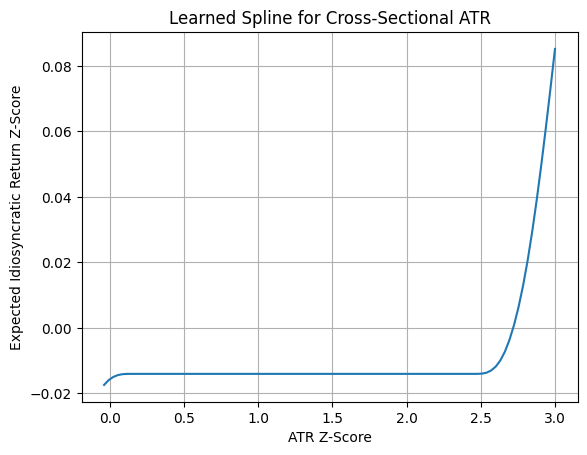

In [11]:
# Phase 4: Model Training (The SCAM)
# Flattening matrices to arrays for PyGAM, masking out non-universe and NaNs
mask = (universe_df == 1) & X_feature.notna() & Y_target.notna()
mask_np = mask.to_numpy()

X_flat = X_feature.to_numpy()[mask_np]
Y_flat = Y_target.to_numpy()[mask_np]

# Split train/val by time to implement Embargo
split_idx = int(len(close_df) * 0.7)
split_date = close_df.index[split_idx]
embargo_date = close_df.index[split_idx + h] # 5-day embargo

print(f"Train end: {split_date}, Val start: {embargo_date}")

# Get boolean masks for Train and Validation sets by date index
dates = np.repeat(close_df.index.values[:, None], close_df.shape[1], axis=1)
dates_flat = dates[mask_np]

train_mask = dates_flat <= split_date.to_numpy()
val_mask = dates_flat >= embargo_date.to_numpy()

X_train, y_train = X_flat[train_mask], Y_flat[train_mask]
X_val, y_val = X_flat[val_mask], Y_flat[val_mask]

# Sample data for speed in training if too large (e.g., take 500k samples)
if len(X_train) > 500000:
    idx = np.random.choice(len(X_train), 500000, replace=False)
    X_train_sub, y_train_sub = X_train[idx], y_train[idx]
else:
    X_train_sub, y_train_sub = X_train, y_train

print(f"Training PyGAM on {len(X_train_sub)} samples...")
# Fit GAM with strictly increasing monotonic constraint
gam = LinearGAM(s(0, constraints='monotonic_inc')).fit(X_train_sub.reshape(-1, 1), y_train_sub)

# Visualize the learned spline
XX = gam.generate_X_grid(term=0)
plt.plot(XX, gam.partial_dependence(term=0, X=XX))
plt.title("Learned Spline for Cross-Sectional ATR")
plt.xlabel("ATR Z-Score")
plt.ylabel("Expected Idiosyncratic Return Z-Score")
plt.grid()
plt.show()


In [12]:
# Phase 5: Alpha Scoring & Portfolio Construction
print("Generating predictions for Validation set...")
# We generate predictions for the entire grid to form a portfolio
# But we only construct the portfolio for the validation period
val_dates = close_df.index[close_df.index >= embargo_date]

X_val_matrix = X_feature.loc[val_dates]
universe_val = universe_df.loc[val_dates]
returns_1d_val = returns_1d.loc[val_dates]

# Predict
predictions = pd.DataFrame(index=X_val_matrix.index, columns=X_val_matrix.columns)
# Flatten, predict, reshape
valid_X = X_val_matrix.notna()
preds_flat = gam.predict(X_val_matrix.values[valid_X].reshape(-1, 1))

# Put back into matrix
pred_vals = np.full(X_val_matrix.shape, np.nan)
pred_vals[valid_X] = preds_flat
predictions[:] = pred_vals

print("Volatility Scaling...")
vol_20 = technical_indicators.volatility_20(close_df).loc[val_dates]
# Inverse volatility weighting
alpha_scores = predictions / (vol_20 + 1e-8)

print("Applying constraints (Dollar Neutrality, Universe)...")
# Apply scale_to_book_long_short across rows (each day)
# Apply 3-day EMA smoothing to raw alpha scores to reduce turnover
alpha_scores_smoothed = alpha_scores.ewm(span=3).mean()
alpha_scaled = alpha_scores_smoothed.apply(utils.scale_to_book_long_short, axis=1)

# Ensure weights are zero where universe is 0
portfolio = pd.DataFrame(index=alpha_scaled.index, columns=alpha_scaled.columns)
for i in range(len(alpha_scaled)):
    portfolio.iloc[i] = utils.get_universe_adjusted_series(alpha_scaled.iloc[i], universe_val.iloc[i])

portfolio = portfolio.fillna(0)
print("Portfolio construction complete.")


Generating predictions for Validation set...
Volatility Scaling...
Applying constraints (Dollar Neutrality, Universe)...
Portfolio construction complete.


In [13]:
# Phase 5.5: Enforce Competition Constraints
# The competition defines the following limits:
# - Target Risk: 500k USD annualised
# - Max Position: 2.5% of 60-day ADV AND $2,000,000
# - Max Traded / Day: 2.5% of 60-day ADV
# - Execution Cost: 2bps
# - Financing Cost: 0.5% annualised on GMV

print("Scaling Unit Portfolio to $500k Target Risk...")
# Calculate the daily PnL of the unit portfolio
unit_pnl = (portfolio * returns_1d_val).sum(axis=1)

# Annualized risk of the unit portfolio (in percentage terms)
unit_annual_risk = unit_pnl.std() * np.sqrt(252)

# If we target exactly 500k risk, we multiply our unit portfolio by:
target_risk = 500_000
risk_scalar = target_risk / unit_annual_risk

dollar_portfolio = portfolio * risk_scalar
print(f"Risk Scalar Applied: ${risk_scalar:,.2f}")

print("Applying Maximum Position Limits...")
# 1. Hard cap at $2M
dollar_portfolio = dollar_portfolio.clip(lower=-2_000_000, upper=2_000_000)

# 2. ADV Limit Cap (2.5% of 60-day ADV)
adv_val = df_adv_60.loc[val_dates]
adv_limit = adv_val * 0.025

# Clip using the dynamic dataframe limit
dollar_portfolio = dollar_portfolio.clip(lower=-adv_limit, upper=adv_limit)

print("Applying Turnover (Max Traded) Limits...")
# The trade size per day is the difference in dollar position.
proposed_trades = dollar_portfolio.diff().fillna(dollar_portfolio)

# Clip the proposed_trades directly and cumsum back to positions
clipped_trades = proposed_trades.clip(lower=-adv_limit, upper=adv_limit)
final_dollar_portfolio = clipped_trades.cumsum()

# Make sure after cumsum we STILL respect the max position limits!
final_dollar_portfolio = final_dollar_portfolio.clip(lower=-2_000_000, upper=2_000_000)
final_dollar_portfolio = final_dollar_portfolio.clip(lower=-adv_limit, upper=adv_limit)


Scaling Unit Portfolio to $500k Target Risk...
Risk Scalar Applied: $5,735,311.21
Applying Maximum Position Limits...
Applying Turnover (Max Traded) Limits...


Running Backtest on Final Dollar Portfolio...
Total Return: $-3,151,136.62
Annualized Risk: $431,746.83 (Target was $500,000)
Net Sharpe Ratio: -1.50


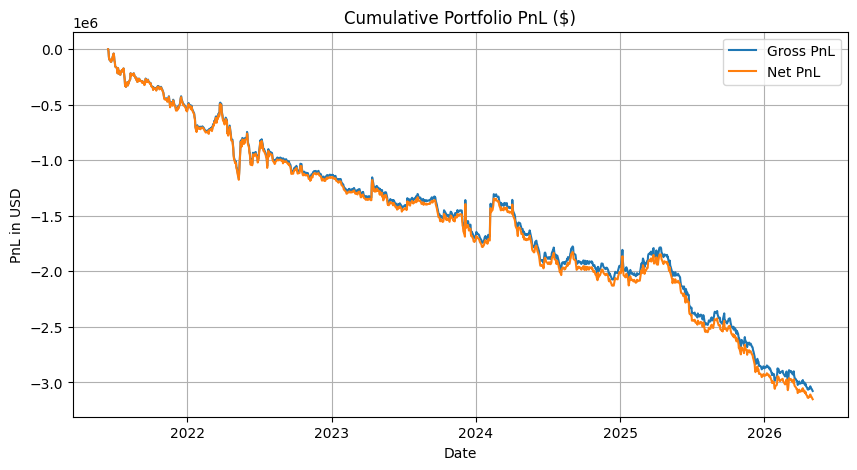

In [14]:
# Phase 6: Execution Simulation & Backtest
print("Running Backtest on Final Dollar Portfolio...")

# 1. Gross PnL (Using final positions and next day returns)
# Since `final_dollar_portfolio` contains weights AT THE END of day t, it earns returns on day t+1
raw_gross_pnl = (final_dollar_portfolio.shift(1) * returns_1d_val).sum(axis=1).fillna(0)

# Auto-Hedging Simulation (QRT Rules)
# We hedge the total portfolio Beta exposure using the market proxy
portfolio_beta_exposure = (final_dollar_portfolio.shift(1) * beta.loc[val_dates]).sum(axis=1).fillna(0)
market_return = returns_1d_val.mean(axis=1).fillna(0)
auto_hedge_pnl = -portfolio_beta_exposure * market_return

gross_pnl = raw_gross_pnl + auto_hedge_pnl

# 2. Execution Costs (2 bps on traded amount)
traded = final_dollar_portfolio.diff().abs().sum(axis=1).fillna(final_dollar_portfolio.abs().sum(axis=1))
execution_costs = traded * 0.0002

# 3. Financing Costs (0.5% annualized on GMV)
gmv = final_dollar_portfolio.abs().sum(axis=1)
financing_costs = gmv * (0.005 / 252)

# 4. Net PnL
net_pnl = gross_pnl - execution_costs - financing_costs

# Metrics
annualized_risk = net_pnl.std() * np.sqrt(252)
sharpe_ratio = (net_pnl.mean() / net_pnl.std()) * np.sqrt(252) if net_pnl.std() != 0 else 0
total_return = net_pnl.sum()

print(f"Total Return: ${total_return:,.2f}")
print(f"Annualized Risk: ${annualized_risk:,.2f} (Target was $500,000)")
print(f"Net Sharpe Ratio: {sharpe_ratio:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(gross_pnl.cumsum(), label='Gross PnL')
plt.plot(net_pnl.cumsum(), label='Net PnL')
plt.title("Cumulative Portfolio PnL ($)")
plt.xlabel("Date")
plt.ylabel("PnL in USD")
plt.legend()
plt.grid()
plt.show()
